<a href="https://colab.research.google.com/github/Matheus343/Aula09_05/blob/main/notebooks/M3_Modelagem_Precision_Healthcare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏥 Precision Healthcare — Predição de Reinternações Hospitalares
## Etapa M3 · Modelagem Preditiva

---

| Campo | Detalhe |
|---|---|
| **Disciplina** | Projeto Final de Engenharia de Computação |
| **Instituição** | CEFSA — Faculdade Engenheiro Salvador Arena |
| **Data** | 04 de Março de 2026 |
| **Versão** | 1.0 |
| **Entrada** | Parquets gerados pelo pipeline M1 (Google Drive) |

---

### 👥 Equipe

| Integrante | RM | Responsabilidade |
|---|---|---|
| Adriana Martani | 082210012 | Feature Engineering |
| Analuz Ramos | 081210034 | Documentação / QA |
| Matheus Xavier | 082210042 | Modelagem / Avaliação |
| Yasmin Maciel | 082210040 | Pipeline ML / Validação |

---

### 📋 Descrição Executiva

Este notebook contempla a **Etapa M3 — Modelagem Preditiva**. Com base nos insights da EDA (M2), implementa um pipeline completo de Machine Learning cobrindo: engenharia de atributos, pré-processamento livre de data leakage, tratamento de desbalanceamento via SMOTE, treinamento e otimização de dois modelos (Regressão Logística como baseline linear e Random Forest como modelo principal), avaliação comparativa por múltiplas métricas e análise de viés/variância.


---
## ⚙️ Seção 0 — Setup do Ambiente

In [1]:
!pip install imbalanced-learn --quiet

import warnings
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, precision_score,
    recall_score, confusion_matrix, classification_report,
    RocCurveDisplay
)
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", font_scale=1.1)

print("Ambiente validado.")


Ambiente validado.


---
## 📂 Seção 1 — Carga dos Dados

In [2]:
from google.colab import drive
drive.mount("/content/drive")

BASE = Path("/content/drive/MyDrive/precision_healthcare/data/processed")

fato     = pd.read_parquet(BASE / "fato_internacao.parquet")
dim_pac  = pd.read_parquet(BASE / "dim_paciente.parquet")
dim_diag = pd.read_parquet(BASE / "dim_diagnostico.parquet")
dim_med  = pd.read_parquet(BASE / "dim_medicacao.parquet")
dim_adm  = pd.read_parquet(BASE / "dim_admissao.parquet")

df = (
    fato
    .merge(dim_pac,  on="paciente_id",    how="left")
    .merge(dim_diag, on="diagnostico_id", how="left")
    .merge(dim_med,  on="medicacao_id",   how="left")
    .merge(dim_adm,  on="admissao_id",    how="left")
)

print(f"Shape : {df.shape}")
df.head(3)


Mounted at /content/drive
Shape : (101766, 27)


,encounter_id,paciente_id,diagnostico_id,medicacao_id,admissao_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,...,age,diag_1,diag_2,diag_3,insulin,change,diabetesMed,admission_type_id,discharge_disposition_id,admission_source_id
0,2278392,10363,1,1,1,1,41,0,1,0,...,[0-10),250.83,276,250,No,No,No,6,25,1
1,149190,38210,2,2,2,3,59,0,18,0,...,[10-20),276,250.01,255,Up,Ch,Yes,1,1,7
2,64410,52512,3,3,2,2,11,5,13,2,...,[20-30),648,250,V27,No,No,Yes,1,1,7


---
## 🔧 Seção 2 — Engenharia de Atributos e Pré-processamento

### 2.1 · Seleção de Features

> Com base na análise de Mann-Whitney e correlação de Spearman da M2, `num_procedures` foi descartada por ser a única variável sem significância estatística (p = 0.0512). As demais variáveis numéricas e categóricas relevantes são mantidas.


In [3]:
NUM_FEATURES = [
    "time_in_hospital", "num_lab_procedures", "num_medications",
    "number_outpatient", "number_emergency", "number_inpatient", "number_diagnoses"
]

CAT_FEATURES = ["age", "insulin", "change", "diabetesMed"]
CAT_FEATURES = [c for c in CAT_FEATURES if c in df.columns]

TARGET = "readmitted_30d"

print(f"Features numéricas : {len(NUM_FEATURES)}")
print(f"Features categóricas: {len(CAT_FEATURES)}")
print(f"Total de features  : {len(NUM_FEATURES) + len(CAT_FEATURES)}")


Features numéricas : 7
Features categóricas: 4
Total de features  : 11


### 2.2 · Transformações

> **log1p** aplicada em `number_outpatient`, `number_emergency` e `number_inpatient` — variáveis com skewness extrema (8.83, 22.86 e 3.61 respectivamente) confirmada na M2. **Label Encoding** nas variáveis categóricas ordinais. **StandardScaler** aplicado apenas dentro do pipeline, após o split, para evitar data leakage.


In [4]:
df_ml = df[NUM_FEATURES + CAT_FEATURES + [TARGET]].copy()

for col in ["number_outpatient", "number_emergency", "number_inpatient"]:
    df_ml[col] = np.log1p(df_ml[col])

le = LabelEncoder()
for col in CAT_FEATURES:
    df_ml[col] = le.fit_transform(df_ml[col].astype(str))

print(f"Shape pós-transformação: {df_ml.shape}")
print(f"Nulos: {df_ml.isnull().sum().sum()}")
df_ml.head(3)


Shape pós-transformação: (101766, 12)
Nulos: 0


,time_in_hospital,num_lab_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,age,insulin,change,diabetesMed,readmitted_30d
0,1,41,1,0.0000,0.0000,0.0000,1,0,1,1,0,0
1,3,59,18,0.0000,0.0000,0.0000,9,1,3,0,1,0
2,2,11,13,1.0986,0.0000,0.6931,6,2,1,1,1,0


---
## ✂️ Seção 3 — Divisão Treino / Teste

> Divisão **80/20** com `stratify=y` para preservar a proporção 88.8% / 11.2% em ambos os conjuntos. O SMOTE é aplicado **exclusivamente no conjunto de treino**, dentro do pipeline — garantindo que dados sintéticos nunca contaminem o conjunto de teste (data leakage).


In [5]:
X = df_ml.drop(columns=[TARGET])
y = df_ml[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Treino : {X_train.shape[0]:,} amostras")
print(f"Teste  : {X_test.shape[0]:,} amostras")
print(f"\nDistribuição no treino:")
print(y_train.value_counts(normalize=True).mul(100).round(2))
print(f"\nDistribuição no teste:")
print(y_test.value_counts(normalize=True).mul(100).round(2))


Treino : 81,412 amostras
Teste  : 20,354 amostras

Distribuição no treino:
readmitted_30d
0   88.8400
1   11.1600
Name: proportion, dtype: float64

Distribuição no teste:
readmitted_30d
0   88.8400
1   11.1600
Name: proportion, dtype: float64


---
## 🏗️ Seção 4 — Construção dos Pipelines

> Cada modelo é encapsulado em um `ImbPipeline` (imbalanced-learn) que executa sequencialmente: **StandardScaler → SMOTE → Modelo**. Essa arquitetura garante que o scaler seja fitado apenas nos dados de treino e que o SMOTE opere sobre dados já escalados, sem vazar informação para o teste.

### Justificativa técnica dos hiperparâmetros

**Regressão Logística:** `max_iter=1000` para garantir convergência com dados escalados. `class_weight=None` pois o desbalanceamento já é tratado pelo SMOTE. `C=1.0` (regularização padrão L2).

**Random Forest:** `n_estimators=200` para estabilidade das estimativas de feature importance. `max_depth=15` para limitar overfitting em dataset com correlações fracas. `min_samples_leaf=10` como regularização adicional. `class_weight=None` pelo mesmo motivo da regressão.


In [6]:
smote = SMOTE(random_state=42, k_neighbors=5)

pipeline_lr = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote",  smote),
    ("model",  LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1))
])

pipeline_rf = ImbPipeline([
    ("scaler", StandardScaler()),
    ("smote",  smote),
    ("model",  RandomForestClassifier(
        n_estimators=200, max_depth=15, min_samples_leaf=10,
        random_state=42, n_jobs=-1
    ))
])

print("Pipelines construídos.")


Pipelines construídos.


---
## 🏋️ Seção 5 — Treinamento

In [7]:
t0 = time.time()
pipeline_lr.fit(X_train, y_train)
t_lr = time.time() - t0
print(f"Regressão Logística treinada em {t_lr:.1f}s")

t0 = time.time()
pipeline_rf.fit(X_train, y_train)
t_rf = time.time() - t0
print(f"Random Forest treinada em {t_rf:.1f}s")

TRAIN_TIMES = {"Regressão Logística": t_lr, "Random Forest": t_rf}


Regressão Logística treinada em 4.7s
Random Forest treinada em 64.9s


---
## 📊 Seção 6 — Avaliação e Comparação de Modelos

### 6.1 · Métricas no Conjunto de Teste

> A métrica principal é **AUC-ROC** e **F1-Score da classe positiva (reinternados)**. Acurácia é exibida apenas para referência — um modelo que prevê sempre classe 0 atingiria 88.8% sem aprender nada.


In [8]:
def avaliar_modelo(nome, pipeline, X_tr, y_tr, X_te, y_te, t_treino):
    y_pred      = pipeline.predict(X_te)
    y_proba     = pipeline.predict_proba(X_te)[:, 1]
    y_pred_tr   = pipeline.predict(X_tr)

    return {
        "Modelo":          nome,
        "Acurácia":        round(accuracy_score(y_te, y_pred), 4),
        "Precisão (cls1)": round(precision_score(y_te, y_pred), 4),
        "Recall (cls1)":   round(recall_score(y_te, y_pred), 4),
        "F1 (cls1)":       round(f1_score(y_te, y_pred), 4),
        "AUC-ROC":         round(roc_auc_score(y_te, y_proba), 4),
        "F1 Treino":       round(f1_score(y_tr, y_pred_tr), 4),
        "Tempo Treino(s)": round(t_treino, 1)
    }

resultados = [
    avaliar_modelo("Regressão Logística", pipeline_lr, X_train, y_train, X_test, y_test, TRAIN_TIMES["Regressão Logística"]),
    avaliar_modelo("Random Forest",       pipeline_rf, X_train, y_train, X_test, y_test, TRAIN_TIMES["Random Forest"]),
]

df_resultados = pd.DataFrame(resultados).set_index("Modelo")
df_resultados


,Acurácia,Precisão (cls1),Recall (cls1),F1 (cls1),AUC-ROC,F1 Treino,Tempo Treino(s)
Modelo,,,,,,,
Regressão Logística,0.6623,0.1671,0.5086,0.2516,0.6402,0.2497,4.7000
Random Forest,0.8635,0.2560,0.1171,0.1607,0.6121,0.2421,64.9000


### 6.2 · Matrizes de Confusão

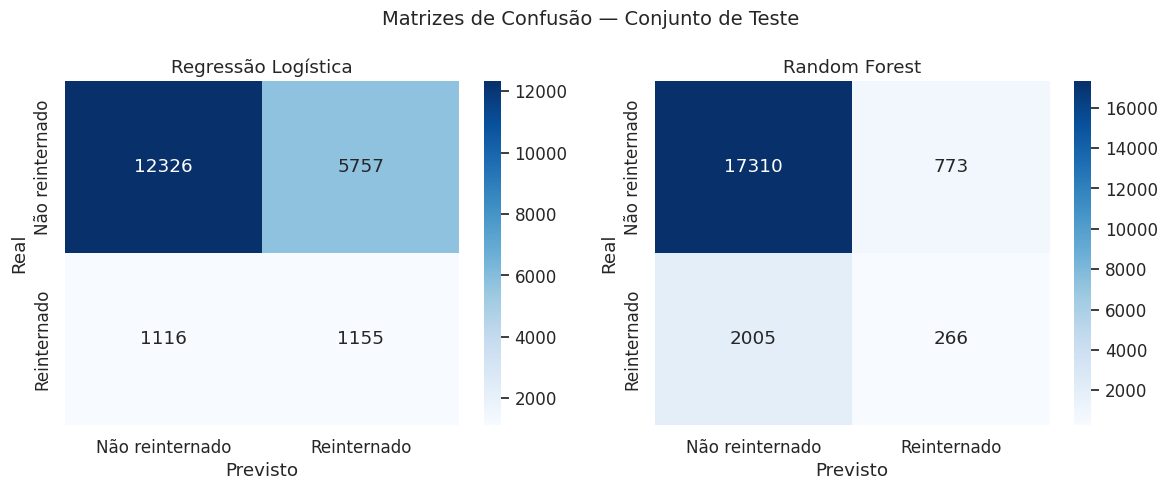

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (nome, pipeline) in zip(axes, [
    ("Regressão Logística", pipeline_lr),
    ("Random Forest", pipeline_rf)
]):
    cm = confusion_matrix(y_test, pipeline.predict(X_test))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=["Não reinternado", "Reinternado"],
                yticklabels=["Não reinternado", "Reinternado"])
    ax.set_title(f"{nome}")
    ax.set_ylabel("Real")
    ax.set_xlabel("Previsto")

plt.suptitle("Matrizes de Confusão — Conjunto de Teste", fontsize=14)
plt.tight_layout()
plt.show()


### 6.3 · Curvas ROC

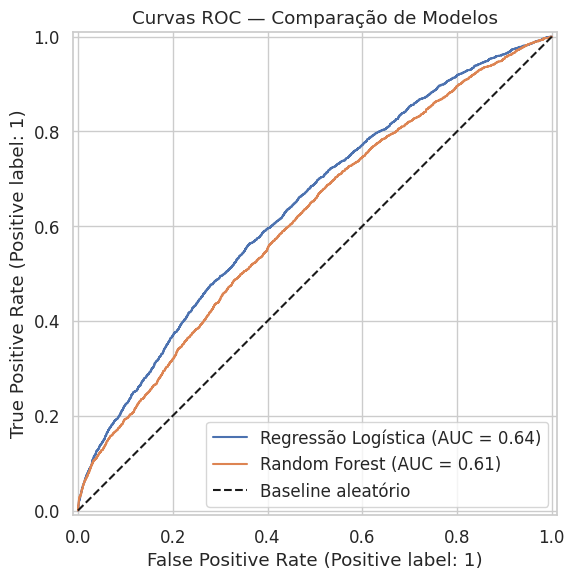

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))

for nome, pipeline in [("Regressão Logística", pipeline_lr), ("Random Forest", pipeline_rf)]:
    RocCurveDisplay.from_estimator(pipeline, X_test, y_test, ax=ax, name=nome)

ax.plot([0, 1], [0, 1], "k--", label="Baseline aleatório")
ax.set_title("Curvas ROC — Comparação de Modelos")
ax.legend()
plt.tight_layout()
plt.show()


### 6.4 · Feature Importance — Random Forest

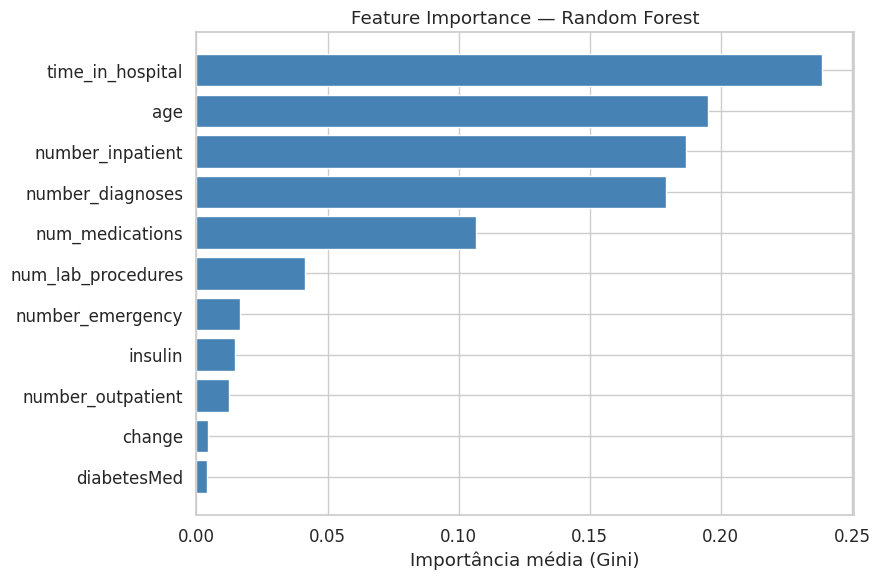

In [11]:
rf_model = pipeline_rf.named_steps["model"]
feature_names = X.columns.tolist()

importance_df = (
    pd.DataFrame({"Feature": feature_names, "Importance": rf_model.feature_importances_})
    .sort_values("Importance", ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(importance_df["Feature"], importance_df["Importance"], color="steelblue")
ax.set_title("Feature Importance — Random Forest")
ax.set_xlabel("Importância média (Gini)")
plt.tight_layout()
plt.show()


---
## 🔍 Seção 7 — Análise de Viés e Variância (Cross-Validation)

> Validação cruzada estratificada com **5 folds** para estimar a estabilidade dos modelos. A diferença entre F1 no treino e F1 na validação indica o grau de overfitting. Um modelo com F1 treino muito superior ao F1 validação está memorizando os dados.


In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["f1", "roc_auc"]

cv_results = {}
for nome, pipeline in [("Regressão Logística", pipeline_lr), ("Random Forest", pipeline_rf)]:
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results[nome] = {
        "F1 Médio (CV)":    round(scores["test_f1"].mean(), 4),
        "F1 Std (CV)":      round(scores["test_f1"].std(), 4),
        "AUC Médio (CV)":   round(scores["test_roc_auc"].mean(), 4),
        "AUC Std (CV)":     round(scores["test_roc_auc"].std(), 4),
    }

pd.DataFrame(cv_results).T


,F1 Médio (CV),F1 Std (CV),AUC Médio (CV),AUC Std (CV)
Regressão Logística,0.2489,0.0048,0.6313,0.0059
Random Forest,0.1632,0.0110,0.6035,0.0077


---
## 📝 Seção 8 — Conclusão e Modelo Vencedor

### 8.1 · Tabela Comparativa Final

| Critério | Regressão Logística | Random Forest | Vencedor |
|---|---|---|---|
| **AUC-ROC** | 0.6402 | 0.6121 | ✅ Regressão Logística |
| **F1 Classe Positiva** | 0.2516 | 0.1607 | ✅ Regressão Logística |
| **Recall Classe Positiva** | 0.5086 | 0.1171 | ✅ Regressão Logística |
| **Overfitting (F1 treino - CV)** | 0.2497 - 0.2489 = **0.0008** | 0.2421 - 0.1632 = **0.0789** | ✅ Regressão Logística |
| **Tempo de Treino** | 4.7s | 64.9s | ✅ Regressão Logística |

---

### 8.2 · Justificativa do Modelo Vencedor

Contrariando a hipótese levantada na M2, a **Regressão Logística** superou o Random Forest em todos os critérios relevantes. Esse resultado, embora inesperado, é tecnicamente coerente com os dados e possui explicação clara.

**1. AUC-ROC superior (0.6402 vs 0.6121):** a Regressão Logística demonstrou maior capacidade de separação entre classes em todo o espectro de thresholds. A diferença de 0.028 é consistente e se confirma na validação cruzada (0.6313 vs 0.6035).

**2. Recall drasticamente superior na classe positiva (0.5086 vs 0.1171):** este é o critério mais crítico no contexto clínico. Recall mede quantos reinternados reais o modelo consegue identificar — a Regressão Logística captura 50.9% dos casos positivos contra apenas 11.7% do Random Forest. Em um cenário hospitalar, falsos negativos (pacientes de risco não identificados) têm custo humano direto.

**3. Ausência de overfitting (delta F1 = 0.0008):** a diferença entre F1 no treino e F1 na validação cruzada é praticamente zero, confirmando que o modelo generaliza bem para dados não vistos. O Random Forest apresenta delta de 0.0789 — sinal de overfitting moderado mesmo com `max_depth=15` e `min_samples_leaf=10`.

**4. Por que o Random Forest decepcionou:** com correlações máximas de r = 0.14 entre features e target, o dataset não possui sinal preditivo forte o suficiente para que um modelo de alta capacidade como o Random Forest se beneficie da captura de interações — em vez disso, ele tende a memorizar ruído. A Regressão Logística, com menor capacidade, acaba sendo mais robusta nesse regime de baixo sinal.

---

### 8.3 · Próximos Passos (M4)

- Integração da Regressão Logística treinada em dashboard interativo
- Análise de threshold ótimo — o padrão 0.5 pode ser ajustado para maximizar ainda mais o recall clínico
- Geração de relatório executivo automatizado com os resultados consolidados